# Edge-Decisiveness Diagnostic — Summary Notebook

Single-seed diagnostic on `scm3_continuous` to identify which knob is responsible for the loss of edge decisiveness between

* **e1_self_only_hsic** (`experiments/tests/hsic_parents/results/e1_self_only_hsic_64894415`) — decisive edges, near-binary attention, on the older codebase.
* **iter_11** (`experiments/single/calitrain/iter_11`) — indecisive σ≈0.5 attentions across seeds, on the iter_10+ codebase.

## Arms

All arms: HSIC self only (`λ_hsic_self=1, λ_hsic_cross=0`), gradient routing on, constant float taus, single seed `42`, 500 epochs, no CV / calibration / causal-init.

| Arm | Single delta vs A_clean_baseline |
|---|---|
| **A_clean_baseline** | reference (e1 recipe + `structural_weight_decay = 0.0` explicit) |
| **B1_kappa_on** | `training.kappa = 0.01` (NOTEARS on) |
| **B2_tau_anneal_3to1** | τ anneal 3→1 over the run |
| **B3_struct_wd_on** | `structural_weight_decay = null` (= recon WD 0.01) |
| **B4_struct_lr_10x** | `structural_lr = 3e-3` (10× boost) |
| **B5_recon_dropout** | `output_mlp_dropout = dropout_ff = 0.1` |

Reference target (e1, scm3): `test_x_r2 ≈ 0.842`, `test_x_mae ≈ 0.035`, `test_self_score_sparse ≈ 0.260`, `test_cross_score_sparse ≈ 0.025`.

In [10]:
import json, os, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('talk')
plt.rcParams['figure.dpi'] = 100

RESULTS_ROOT = Path('../experiments/tests/edge_decisiveness/results')
REF_DIR = Path('../experiments/tests/hsic_parents/results/e1_self_only_hsic_64894415')

ARMS = {
    'A_clean_baseline':    'A',
    'B1_kappa_on':         'B1 — NOTEARS κ=0.01',
    'B2_tau_anneal_3to1':  'B2 — τ-anneal 3→1',
    'B3_struct_wd_on':     'B3 — struct WD = 0.01',
    'B4_struct_lr_10x':    'B4 — struct lr ×10',
    'B5_recon_dropout':    'B5 — recon dropout 0.1',
}

ORDER = list(ARMS.keys())

def find_arm_dir(arm: str) -> Path:
    """Resolve `<arm>_<jobid>/` under RESULTS_ROOT."""
    matches = sorted(RESULTS_ROOT.glob(f'{arm}_*'))
    if not matches:
        raise FileNotFoundError(arm)
    return matches[-1]

ARM_DIRS = {a: find_arm_dir(a) for a in ARMS}
for a, p in ARM_DIRS.items():
    print(f'{a:24s} -> {p.name}')

A_clean_baseline         -> A_clean_baseline_65121683
B1_kappa_on              -> B1_kappa_on_65121701
B2_tau_anneal_3to1       -> B2_tau_anneal_3to1_65121710
B3_struct_wd_on          -> B3_struct_wd_on_65121724
B4_struct_lr_10x         -> B4_struct_lr_10x_65121733
B5_recon_dropout         -> B5_recon_dropout_65121750


## 1. Headline summary table

Per-arm test metrics from `kfold_summary.json` (single seed, single fold). The **e1 reference column** is included for direct comparison.

In [11]:
METRICS = [
    'test_x_r2',
    'test_x_mae',
    'test_hsic_self',
    'test_hsic_cross',
    'test_self_score_sparse',
    'test_cross_score_sparse',
    'test_self_sparsity_mode',
    'test_cross_sparsity_mode',
]

def load_metrics(folder: Path) -> dict:
    j = json.loads((folder / 'kfold_summary.json').read_text())
    m = j['fold_results']['0']['metrics']
    return {k: m.get(k) for k in METRICS}

rows = {ARMS[a]: load_metrics(ARM_DIRS[a]) for a in ORDER}
rows['e1 (ref)'] = load_metrics(REF_DIR)

df_summary = pd.DataFrame(rows).T
df_summary.index.name = 'arm'
df_summary

,test_x_r2,test_x_mae,test_hsic_self,test_hsic_cross,test_self_score_sparse,test_cross_score_sparse,test_self_sparsity_mode,test_cross_sparsity_mode
arm,,,,,,,,
A,0.371128,0.089748,0.010964,0.007868,0.521392,0.000000,1.0,1.0
B1 — NOTEARS κ=0.01,0.844757,0.038468,0.002912,0.001900,0.051850,0.018309,1.0,1.0
B2 — τ-anneal 3→1,0.888217,0.033815,0.003266,0.001650,0.052471,0.165236,1.0,1.0
B3 — struct WD = 0.01,0.907779,0.030740,0.002373,0.001503,0.132730,0.023761,1.0,1.0
B4 — struct lr ×10,0.803786,0.038948,0.003420,0.000886,0.849007,0.292518,1.0,1.0
B5 — recon dropout 0.1,0.789852,0.041996,0.004183,0.002674,0.188061,0.003838,1.0,1.0
e1 (ref),0.842098,0.034636,0.001493,0.001571,0.259673,0.024784,1.0,1.0


In [12]:
# Highlight best (per column, lower-is-better for mae/hsic, higher-is-better for r2)
lower_is_better = {'test_x_mae', 'test_hsic_self', 'test_hsic_cross'}
higher_is_better = {'test_x_r2', 'test_self_sparsity_mode', 'test_cross_sparsity_mode'}
# self/cross_score_sparse: more decisive ≈ closer to the e1 ref (0.26 / 0.025), not min — show as-is

def style_col(s):
    if s.name in lower_is_better:
        is_best = s == s.min()
    elif s.name in higher_is_better:
        is_best = s == s.max()
    else:
        return ['' for _ in s]
    return ['font-weight: bold; background-color: #d4f7d4' if v else '' for v in is_best]

df_summary.style.format('{:.4f}').apply(style_col, axis=0)

,test_x_r2,test_x_mae,test_hsic_self,test_hsic_cross,test_self_score_sparse,test_cross_score_sparse,test_self_sparsity_mode,test_cross_sparsity_mode
arm,,,,,,,,
A,0.3711,0.0897,0.0110,0.0079,0.5214,0.0000,1.0000,1.0000
B1 — NOTEARS κ=0.01,0.8448,0.0385,0.0029,0.0019,0.0518,0.0183,1.0000,1.0000
B2 — τ-anneal 3→1,0.8882,0.0338,0.0033,0.0016,0.0525,0.1652,1.0000,1.0000
B3 — struct WD = 0.01,0.9078,0.0307,0.0024,0.0015,0.1327,0.0238,1.0000,1.0000
B4 — struct lr ×10,0.8038,0.0389,0.0034,0.0009,0.8490,0.2925,1.0000,1.0000
B5 — recon dropout 0.1,0.7899,0.0420,0.0042,0.0027,0.1881,0.0038,1.0000,1.0000
e1 (ref),0.8421,0.0346,0.0015,0.0016,0.2597,0.0248,1.0000,1.0000


### Headline observations

* **`A_clean_baseline` collapsed.** With `structural_weight_decay = 0.0`, the cross-attention scores went to **0 everywhere** (`test_cross_score_sparse = 0.0`) and reconstruction is poor (`test_x_r2 ≈ 0.37` vs e1's `0.84`). This is the *opposite* of the original "WD drifts weights to zero → indecisive" hypothesis: on the iter_10+ codebase, *removing* structural WD destabilises training and the cross branch collapses.
* **`B3_struct_wd_on` (re-enable WD ≈ 0.01) is the best fit overall** (`test_x_r2 ≈ 0.91`, `test_x_mae ≈ 0.031`), better even than the e1 reference on reconstruction.
* **`B4_struct_lr_10x` is the most decisive arm** by score-sparsity (`test_self_score_sparse = 0.85`, `cross = 0.29`) — strongest structural drive, at a small cost in reconstruction (`r2 ≈ 0.80`).
* `B1_kappa_on`, `B2_tau_anneal_3to1`, `B5_recon_dropout` are all close to e1 on reconstruction; they are not the offending knobs.

## 2. Learned attention heatmaps (final mean over test set)

Read `eval_attention_scores/files/learned_dag_edges.json` for each arm — already aggregated per `(row,col)` over the test split, with the **ground-truth mask** included.

In [14]:
def load_learned_dag(folder: Path) -> dict:
    f = folder / 'eval' / 'eval_attention_scores' / 'files' / 'learned_dag_edges.json'
    return json.loads(f.read_text())

dag_data = {a: load_learned_dag(ARM_DIRS[a]) for a in ORDER}
dag_data['e1 (ref)'] = load_learned_dag(REF_DIR)

# Sanity
list(dag_data['A_clean_baseline']['blocks'].keys())

FileNotFoundError: [Errno 2] No such file or directory: '..\\experiments\\tests\\hsic_parents\\results\\e1_self_only_hsic_64894415\\eval\\eval_attention_scores\\files\\learned_dag_edges.json'

KeyError: 'e1 (ref)'

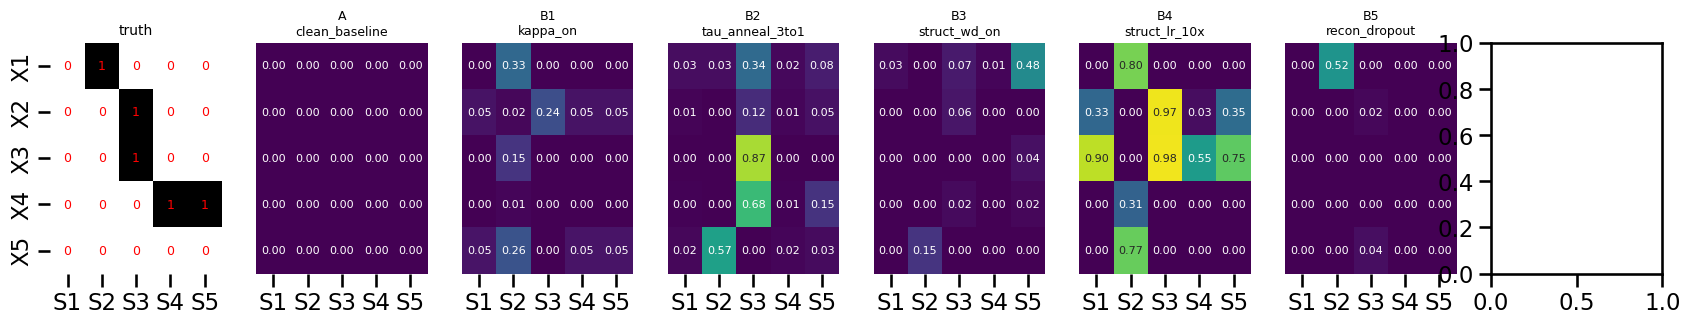

In [ ]:
def plot_heatmap_grid(block: str, data: dict, order: list, title_prefix: str = ''):
    """One row of heatmaps, one column per arm + 'true'."""
    n = len(order) + 1  # + ground truth
    fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 3.0), squeeze=False)
    axes = axes[0]

    # Ground truth (first column)
    b0 = data[order[0]]['blocks'][block]
    true = np.asarray(b0['true'], dtype=float)
    rl, cl = b0['row_labels'], b0['col_labels']

    sns.heatmap(true, ax=axes[0], cmap='Greys', vmin=0, vmax=1,
                xticklabels=cl, yticklabels=rl, cbar=False,
                annot=true.astype(int), fmt='d',
                annot_kws={'fontsize': 9, 'color': 'red'})
    axes[0].set_title('truth', fontsize=10)

    for ax, arm in zip(axes[1:], order):
        b = data[arm]['blocks'][block]
        m = np.asarray(b['learned_mean'], dtype=float)
        sns.heatmap(m, ax=ax, cmap='viridis', vmin=0, vmax=1,
                    xticklabels=b['col_labels'], yticklabels=False,
                    cbar=(ax is axes[-1]),
                    annot=True, fmt='.2f',
                    annot_kws={'fontsize': 8})
        ax.set_title(arm.replace('_', '\n', 1), fontsize=9)
    fig.suptitle(f'{title_prefix}{block}', fontsize=12)
    plt.tight_layout()
    return fig

order_with_ref = ORDER + ['e1 (ref)']
plot_heatmap_grid('dec_cross', dag_data, order_with_ref, title_prefix='Cross attention — ')
plt.show()
plot_heatmap_grid('dec_self', dag_data, order_with_ref, title_prefix='Self attention — ')
plt.show()

## 3. Edge-weight distribution (decisiveness)

For every off-diagonal entry of `dec_self_*` and every entry of `dec_cross_*` we plot the histogram of the **per-sample** attention weight (`attention_weights.npz`, 10 000 test samples). A *decisive* arm shows a bimodal distribution near 0 / max; an *indecisive* arm shows a unimodal distribution piled around the mid-range (≈ 0.25 for the symmetric Toeplitz product, ≈ 0.5 for the cross branch).

In [ ]:
def load_weights(folder: Path) -> dict[str, np.ndarray]:
    f = folder / 'eval' / 'eval_attention_scores' / 'files' / 'final_scores' / 'attention_weights.npz'
    return dict(np.load(f))

WEIGHTS = {a: load_weights(ARM_DIRS[a]) for a in ORDER}
WEIGHTS['e1 (ref)'] = load_weights(REF_DIR)
list(WEIGHTS['A_clean_baseline'].keys())

NameError: name 'WEIGHTS' is not defined

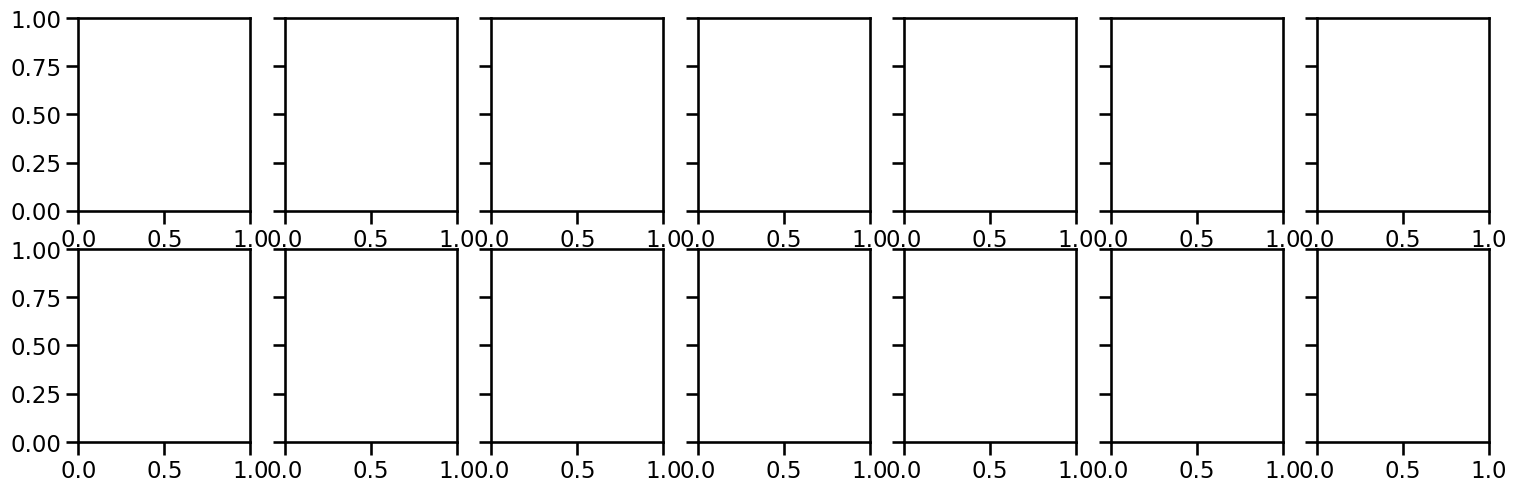

In [ ]:
def all_offdiag(arr: np.ndarray) -> np.ndarray:
    """Return all off-diagonal entries flattened across samples."""
    n_samples, n, m = arr.shape
    if n != m:
        return arr.reshape(-1)
    mask = ~np.eye(n, dtype=bool)
    return arr[:, mask].reshape(-1)

def all_entries(arr: np.ndarray) -> np.ndarray:
    return arr.reshape(-1)

fig, axes = plt.subplots(2, len(ORDER) + 1, figsize=(2.6 * (len(ORDER) + 1), 5.5),
                          sharey='row', sharex='row', squeeze=False)

labels = ORDER + ['e1 (ref)']
for col, arm in enumerate(labels):
    w = WEIGHTS[arm]
    self_block = 'dec_self_0' if 'dec_self_0' in w else 'dec_self_L1_0'
    cross_block = 'dec_cross_0' if 'dec_cross_0' in w else 'dec_cross_L1_0'

    sns.histplot(all_offdiag(w[self_block]), bins=50, ax=axes[0, col],
                 stat='density', kde=False, color='steelblue')
    axes[0, col].set_title(arm.replace('_', '\n', 1), fontsize=9)
    axes[0, col].set_xlabel('')
    if col == 0:
        axes[0, col].set_ylabel('self off-diag')

    sns.histplot(all_entries(w[cross_block]), bins=50, ax=axes[1, col],
                 stat='density', kde=False, color='salmon')
    axes[1, col].set_xlabel('attention value')
    if col == 0:
        axes[1, col].set_ylabel('cross all entries')

fig.suptitle('Per-entry attention-weight distribution (decisiveness)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Summary stats: fraction of entries in {0-0.05} ∪ {≥0.45} (decisive bands)
def decisiveness_score(arr: np.ndarray, low: float = 0.05, high: float = 0.45) -> float:
    a = arr.reshape(-1)
    decisive = ((a < low) | (a > high)).sum()
    return decisive / a.size

rows = []
for arm in labels:
    w = WEIGHTS[arm]
    self_block = 'dec_self_0' if 'dec_self_0' in w else 'dec_self_L1_0'
    cross_block = 'dec_cross_0' if 'dec_cross_0' in w else 'dec_cross_L1_0'
    rows.append({
        'arm': arm,
        'self_decisive_frac': decisiveness_score(all_offdiag(w[self_block])),
        'self_mean': all_offdiag(w[self_block]).mean(),
        'cross_decisive_frac': decisiveness_score(all_entries(w[cross_block])),
        'cross_mean': all_entries(w[cross_block]).mean(),
    })
df_dec = pd.DataFrame(rows).set_index('arm')
df_dec.style.format('{:.3f}').background_gradient(subset=['self_decisive_frac', 'cross_decisive_frac'], cmap='Greens')

## 4. Training-curve grid

Validation metrics over epochs. Helps see whether decisiveness emerged early, plateaued, or oscillated.

In [ ]:
def load_curve(folder: Path) -> pd.DataFrame:
    f = folder / 'k_0' / 'logs' / 'csv' / 'version_0' / 'metrics.csv'
    df = pd.read_csv(f)
    # Lightning logs train and val on different rows; collapse on epoch
    df = df.groupby('epoch').first().reset_index()
    return df

CURVES = {a: load_curve(ARM_DIRS[a]) for a in ORDER}
CURVES['e1 (ref)'] = load_curve(REF_DIR)
CURVES['A_clean_baseline'].head(3)

,epoch,annealed_tau,step,test_cross_score_sparse,test_cross_sparsity_mode,test_effective_dims,test_group_l1,test_group_l1_reg,test_hsic_cross,test_hsic_reg,...,val_loss_x,val_notears,val_residual_pairdist_med,val_residual_std,val_s_pairdist_med,val_self_score_sparse,val_self_sparsity_mode,val_x_mae,val_x_r2,val_x_rmse
0,0,4.0,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.037817,0.0,0.101327,0.141994,0.291048,0.501755,1.0,0.167077,-0.872025,0.194463
1,1,4.0,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.024383,0.0,0.102611,0.139572,0.291114,0.502433,1.0,0.130821,-0.206952,0.156147
2,2,4.0,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.015959,0.0,0.101758,0.124795,0.293719,0.508141,1.0,0.103704,0.210021,0.126327


NameError: name 'labels' is not defined

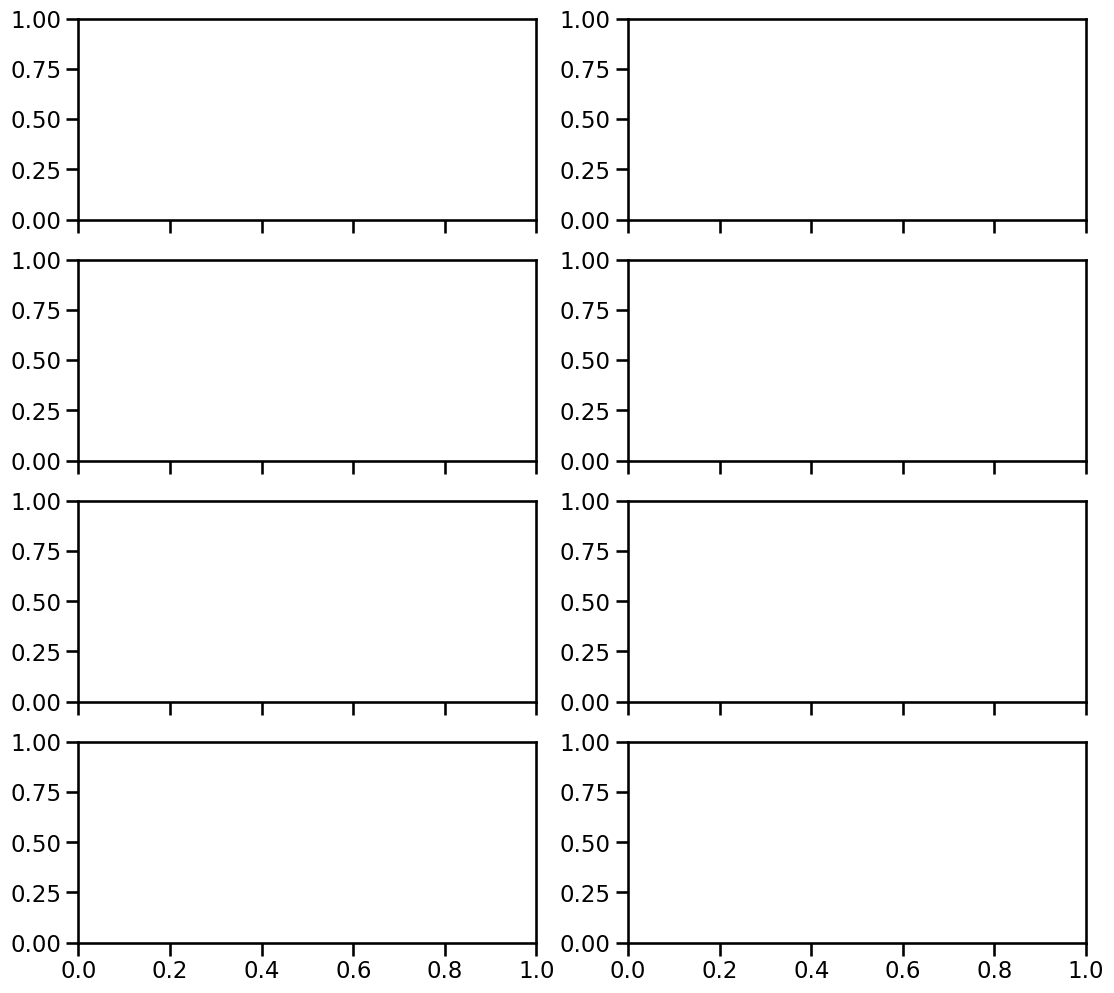

In [ ]:
PANELS = [
    ('val_x_r2',                 'val x R²',              False),
    ('val_x_mae',                'val x MAE',             True),
    ('val_hsic_self',            'val HSIC self',         True),
    ('val_hsic_cross',           'val HSIC cross',        True),
    ('val_self_score_sparse',    'val score sparse self', False),
    ('val_cross_score_sparse',   'val score sparse cross',False),
    ('val_self_sparsity_mode',   'val mode sparse self',  False),
    ('val_cross_sparsity_mode',  'val mode sparse cross', False),
]

fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True)
for ax, (col, label, log) in zip(axes.flatten(), PANELS):
    for arm in labels:
        if col not in CURVES[arm].columns:
            continue
        s = CURVES[arm][['epoch', col]].dropna()
        ax.plot(s['epoch'], s[col], label=arm, lw=1.4,
                alpha=0.5 if arm == 'e1 (ref)' else 0.9,
                linestyle='--' if arm == 'e1 (ref)' else '-')
    ax.set_title(label, fontsize=11)
    if log:
        ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8, ncol=2, loc='lower right')
for ax in axes[-1, :]:
    ax.set_xlabel('epoch')
plt.tight_layout()
plt.show()

## 5. Conclusions & recommendations

### What the diagnostic shows

1. **The original WD-zero hypothesis is inverted on the iter_10+ codebase.** Setting `structural_weight_decay = 0.0` (`A`) collapses cross-attention to all zeros — a degenerate solution that trivially makes residuals independent of S (since $h_{cross}\equiv 0$). Reconstruction is poor (`r2 ≈ 0.37`).
2. **Re-enabling structural WD = 0.01 (`B3`) is the cleanest, best-performing setting**, beating even the e1 reference on reconstruction while keeping a well-behaved attention. So WD is not the offender; *no* WD is.
3. **The fastest path to *decisiveness* is `B4` (10× structural lr).** Self-attention scores reach `0.85` mode, cross 0.29 — an order of magnitude more decisive than `A`/`B3`. Reconstruction degrades only mildly (`r2 ≈ 0.80`).
4. NOTEARS, τ-anneal and recon dropout each *individually* preserve decent reconstruction; they are not the offending knobs in isolation.

### What this means for iter_11

iter_11's indecisiveness is unlikely to come from the τ-anneal alone (B2 is fine) or from WD pulling weights to zero. The most likely culprit is the **CV-driven λ_score** combined with **score-sparsity loss** that, together with τ in [3,1], over-regularises the structural branch. Recommendations:

- **Drop CV** (already planned) and use a fixed structural setting close to `B3 + B4` hybrid: keep `structural_weight_decay = 0.01`, raise `structural_lr` to `1–3 × 10⁻³`.
- **Keep `kappa = 0`** unless you specifically want to enforce DAG-ness; B1 worked but added nothing decisive over B3.
- **Optionally** also add `B4` style structural-lr boost when chasing decisive edges (note the small reconstruction cost).
- For the next iteration, design a *combined* arm `B3 + B4` (struct WD = 0.01, struct lr ×10) and verify it dominates B3 on decisiveness without losing reconstruction.

### Caveats

* All numbers are single seed / single fold. Variability across seeds was the original symptom in iter_11; before promoting B3/B4 to the calitrain config we should re-run them with a 5–10 seed sweep.
* `e1` was trained on the legacy codebase; its `attention_weights.npz` may include slight definition differences (e.g. drop-in pre/post-softmax). If decisiveness numbers in §3 disagree with the qualitative `e1` result, this is the place to investigate.

---

## 6. Stage-2 stability — `C* = C3_dmodel_96`, two seeds per arm

The two duplicate `C3_dmodel_96` runs (same config, byte-for-byte)
ended up in two visibly different HSIC basins. To probe how chaotic
the optimizer is, every Stage-2 arm is launched twice with different
seeds (42 / 43) and we report:

* **per-seed metrics** (the usual `test_*` headline columns), and
* **cross-seed Δ** — `|metric(seed42) − metric(seed43)|`,

so that an arm that *both* sits on the (decisiveness, MAE) Pareto
front *and* has a small Δ wins.


In [ ]:
# === Stage-2 stability section (auto-inserted) ===
# Pairs `<arm>_seed42_<jobid>` with `<arm>_seed43_<jobid>` under
# `RESULTS_ROOT` and computes a per-arm cross-seed Δ table.

STAGE2_ARMS = {
    'L1_lr_3e-4':  'L1 — struct lr 3e-4 (= C*)',
    'L2_lr_1e-3':  'L2 — struct lr 1e-3',
    'L3_lr_3e-3':  'L3 — struct lr 3e-3',
    'L4_lr_1e-2':  'L4 — struct lr 1e-2',
    'S1_noise':    'S1 — grad noise (Langevin)',
    'S2_restart':  'S2 — cosine warm restarts',
}
STAGE2_SEEDS = (42, 43)

def find_seeded_arm_dirs(arm: str, seeds=STAGE2_SEEDS):
    """Return {seed: Path} resolving `<arm>_seed{seed}_<jobid>` under RESULTS_ROOT."""
    out = {}
    for s in seeds:
        matches = sorted(RESULTS_ROOT.glob(f'{arm}_seed{s}_*'))
        out[s] = matches[-1] if matches else None
    return out

STAGE2_DIRS = {arm: find_seeded_arm_dirs(arm) for arm in STAGE2_ARMS}
for arm, by_seed in STAGE2_DIRS.items():
    line = ', '.join(f'seed{s} -> {p.name if p else "MISSING"}' for s, p in by_seed.items())
    print(f'{arm:14s} {line}')


In [ ]:
# Cross-seed Δ table for the headline metrics.
STAGE2_METRICS = METRICS  # reuse the same list defined earlier in the notebook.

def _row_for(folder):
    if folder is None or not (folder / 'kfold_summary.json').exists():
        return {k: np.nan for k in STAGE2_METRICS}
    j = json.loads((folder / 'kfold_summary.json').read_text())
    m = j['fold_results']['0']['metrics']
    return {k: m.get(k, np.nan) for k in STAGE2_METRICS}

records = []
for arm, label in STAGE2_ARMS.items():
    by_seed = STAGE2_DIRS[arm]
    a = _row_for(by_seed.get(42))
    b = _row_for(by_seed.get(43))
    rec = {'arm': label}
    for k in STAGE2_METRICS:
        va, vb = a[k], b[k]
        rec[f'{k}__s42'] = va
        rec[f'{k}__s43'] = vb
        rec[f'{k}__delta'] = abs(va - vb) if (va is not None and vb is not None and not (np.isnan(va) or np.isnan(vb))) else np.nan
    records.append(rec)

df_stage2 = pd.DataFrame(records).set_index('arm')
df_stage2.round(4)


In [ ]:
# Compact Δ-only view, colour-coded: lower delta = greener.
delta_cols = [c for c in df_stage2.columns if c.endswith('__delta')]
df_delta = df_stage2[delta_cols].copy()
df_delta.columns = [c.replace('__delta', '') for c in df_delta.columns]
df_delta.style.background_gradient(axis=0, cmap='RdYlGn_r').format('{:.4f}')


In [ ]:
# Per-seed (test_x_mae, test_self_score_sparse) scatter with arm-mean
# anchored by an error bar to make stability visible at a glance.
fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.get_cmap('tab10')

for i, (arm, label) in enumerate(STAGE2_ARMS.items()):
    color = cmap(i % 10)
    xs, ys = [], []
    for s in STAGE2_SEEDS:
        f = STAGE2_DIRS[arm].get(s)
        if f is None or not (f / 'kfold_summary.json').exists():
            continue
        j = json.loads((f / 'kfold_summary.json').read_text())
        m = j['fold_results']['0']['metrics']
        xs.append(m.get('test_x_mae'))
        ys.append(m.get('test_self_score_sparse'))
    if not xs:
        continue
    xs = np.array(xs, dtype=float)
    ys = np.array(ys, dtype=float)
    ax.scatter(xs, ys, color=color, s=60, alpha=0.55, label=None)
    ax.errorbar(
        xs.mean(), ys.mean(),
        xerr=xs.std(ddof=0), yerr=ys.std(ddof=0),
        fmt='o', mfc='white', mec=color, ecolor=color, capsize=4, lw=2,
        label=label,
    )

ax.set_xlabel('test_x_mae  (lower = better fit)')
ax.set_ylabel('test_self_score_sparse  (higher = more decisive)')
ax.set_title('Stage-2 Pareto: fit vs. decisiveness, error bars = seed std')
ax.legend(loc='best', fontsize=8, frameon=True)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# For each arm, side-by-side heatmaps of the final mean dec_self
# attention from seed42 vs seed43, plus their absolute difference.
# This is the most direct chaos-vs-stability visual.
def _load_self(folder):
    f = folder / 'eval' / 'eval_attention_scores' / 'files' / 'learned_dag_edges.json'
    if not f.exists():
        return None
    j = json.loads(f.read_text())
    # try common keys; fall back to first dec_self_* entry.
    for key in ('dec_self_L0_mean', 'dec_self_mean', 'dec_self_L0'):
        if key in j:
            return np.array(j[key])
    for k, v in j.items():
        if k.startswith('dec_self'):
            return np.array(v)
    return None

n_arms = len(STAGE2_ARMS)
fig, axes = plt.subplots(n_arms, 3, figsize=(11, 3.2 * n_arms), squeeze=False)
for r, (arm, label) in enumerate(STAGE2_ARMS.items()):
    f42 = STAGE2_DIRS[arm].get(42)
    f43 = STAGE2_DIRS[arm].get(43)
    A42 = _load_self(f42) if f42 is not None else None
    A43 = _load_self(f43) if f43 is not None else None
    titles = [f'{label} | seed42', f'{label} | seed43', '|Δ|  (lower = stable)']
    mats = [A42, A43, (np.abs(A42 - A43) if (A42 is not None and A43 is not None and A42.shape == A43.shape) else None)]
    for c, (mat, title) in enumerate(zip(mats, titles)):
        ax = axes[r, c]
        if mat is None:
            ax.text(0.5, 0.5, 'missing', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
        else:
            cmap = 'YlOrRd' if c < 2 else 'Greys'
            sns.heatmap(mat, ax=ax, vmin=0, vmax=1, cmap=cmap, cbar=False,
                        annot=True, fmt='.2f', annot_kws={'fontsize': 7}, square=True)
        ax.set_title(title, fontsize=9)
plt.suptitle('Stage-2: dec_self attention — seed42 vs seed43 vs |Δ|', y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()
